In [1]:
import numpy as np
import matplotlib.pyplot as plt 
import pandas as pd  
import seaborn as sns 
from sklearn.datasets import load_iris
pd.options.mode.chained_assignment = None  # 忽略警告

In [3]:
X_df = sns.load_dataset("iris")

In [4]:
def heatmap_sum(data, i_array, j_array, title, vmin, vmax, cmap):
    """绘制热力图，显示矩阵数据的分布情况"""
    fig, ax = plt.subplots(figsize=(10, 10))
    ax = sns.heatmap(data, cmap=cmap,
                     cbar_kws={"orientation": "horizontal"},
                     yticklabels=i_array, xticklabels=j_array,
                     ax=ax, annot=True,
                     linewidths=0.25, linecolor='grey',
                     vmin=vmin, vmax=vmax)
    ax.set_xlabel('Sepal length')  # 设置X轴标签
    ax.set_ylabel('Sepal width')  # 设置Y轴标签
    ax.set_aspect("equal")
    plt.title(title)
    plt.yticks(rotation=0) 

In [6]:
#round四舍五入到整数
#*2 /2 的效果是0.5为单位的四舍五入
X_df.sepal_length = round(X_df.sepal_length * 2) / 2  # 四舍五入
X_df.sepal_width = round(X_df.sepal_width * 2) / 2  # 四舍五入

In [7]:
sepal_length_array = np.sort(X_df.sepal_length.unique())  # 排序花萼长度
sepal_width_array = -np.sort(-X_df.sepal_width.unique())  # 逆序花萼宽度

In [8]:
X_df_12 = X_df[['sepal_length', 'sepal_width']]
X_df_12['count'] = 1  # 添加计数列

In [9]:
#.groupby(['a', 'b'])得到的一个中间待处理状态的值
#第二步记数且生成了一个df,这里之前的数据出了新添加的都变成了多层行索引
#第三步level = 0表示这一层的行索引变列索引
frequency_matrix = X_df_12.groupby(['sepal_length', 'sepal_width']).count().unstack(level=0)  # 计算频数矩阵
#列索引多加了一列,这里把之前的count删了
frequency_matrix.columns = frequency_matrix.columns.droplevel(0)
#nan替换为0
#-1是对y上下翻行,默认操作是从上到下小到大,变为大到小符合绘图习惯
frequency_matrix = frequency_matrix.fillna(0).iloc[::-1]

In [10]:
probability_matrix = frequency_matrix / 150  # 概率矩阵
probability_matrix_ = probability_matrix.to_numpy()

In [11]:
#unique去除重复值
X1_array = np.sort(X_df.sepal_length.unique()).reshape(1, -1)
X2_array = np.sort(X_df.sepal_width.unique())[::-1].reshape(1, -1)

In [12]:
marginal_X1 = probability_matrix.sum(axis=0).to_numpy().reshape((1, -1))
marginal_X2 = probability_matrix.sum(axis=1).to_numpy().reshape((-1, 1))

In [13]:
conditional_X2_given_X1_matrix = probability_matrix_ / (np.ones((6, 1)) @ np.array([probability_matrix_.sum(axis=0)]))

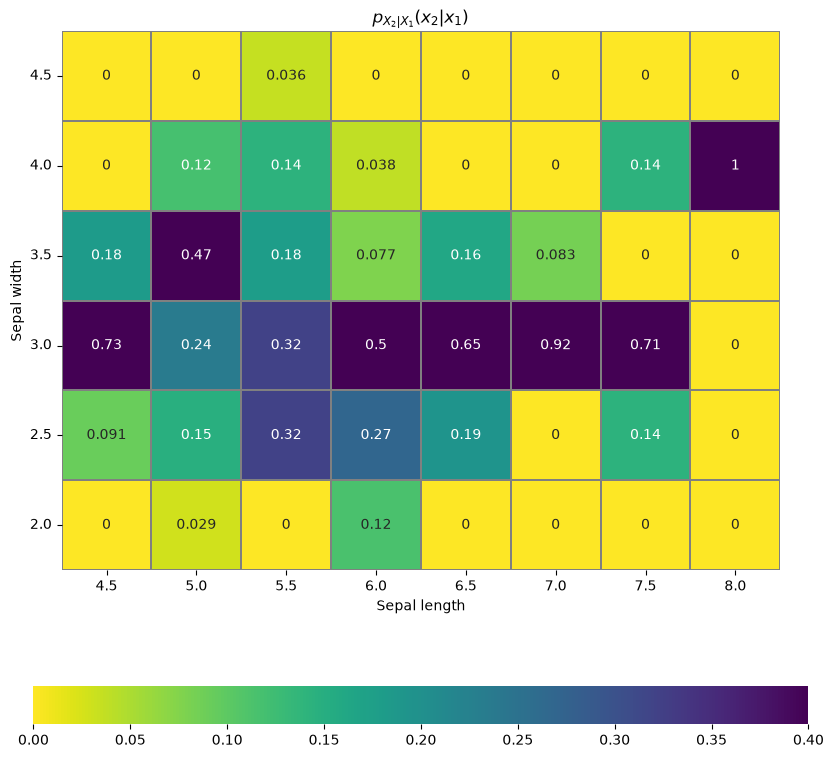

In [14]:
title = '$p_{X_2 | X_1}(x_2 | x_1)$'
heatmap_sum(conditional_X2_given_X1_matrix, sepal_width_array, sepal_length_array, title, 0, 0.4, 'viridis_r')

In [15]:
E_X2_given_X1 = X2_array @ conditional_X2_given_X1_matrix  # 条件期望计算

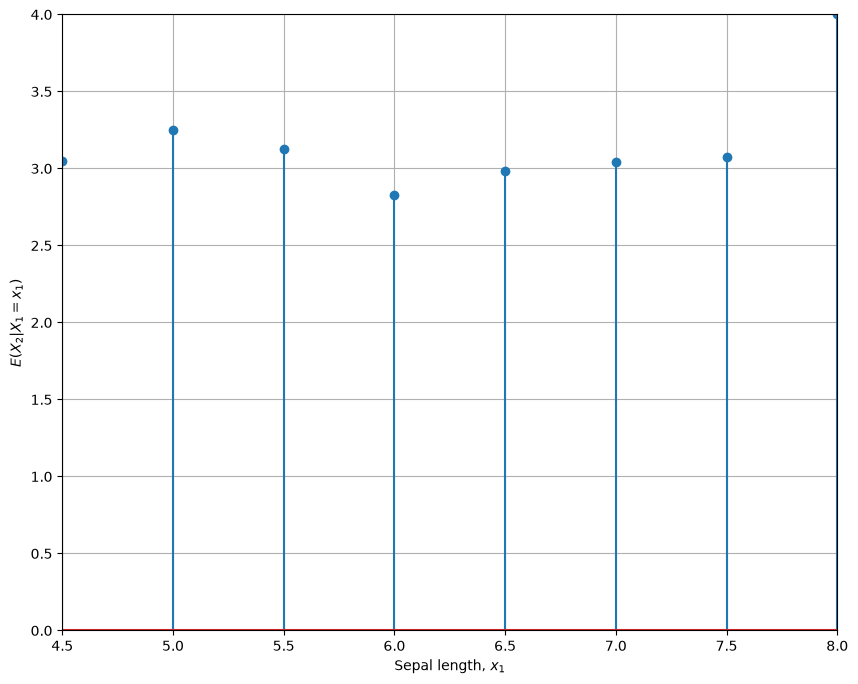

In [16]:
fig, ax = plt.subplots(figsize=(10, 8))
plt.stem(X1_array.T, E_X2_given_X1.T) # , use_line_collection=True
plt.xlabel('Sepal length, $x_1$')
plt.ylabel('$E(X_2 | X_1 = x_1)$')
plt.grid()
plt.xlim(4.5, 8.0)
plt.ylim(0, 4)
plt.show()

In [17]:
E_X2 = E_X2_given_X1 @ marginal_X1.T  # X2的总期望

In [22]:
E_X2_ = X_df_12['sepal_width'].mean()  # 检验总期望计算结果

In [23]:
print(E_X2)
print(E_X2_)

[[3.06333333]]
3.0633333333333335


In [20]:
E_X2_sq_given_X1 = (X2_array**2)@conditional_X2_given_X1_matrix

In [21]:
var_X2_given_X1 = E_X2_sq_given_X1 - E_X2_given_X1**2  # 计算条件方差

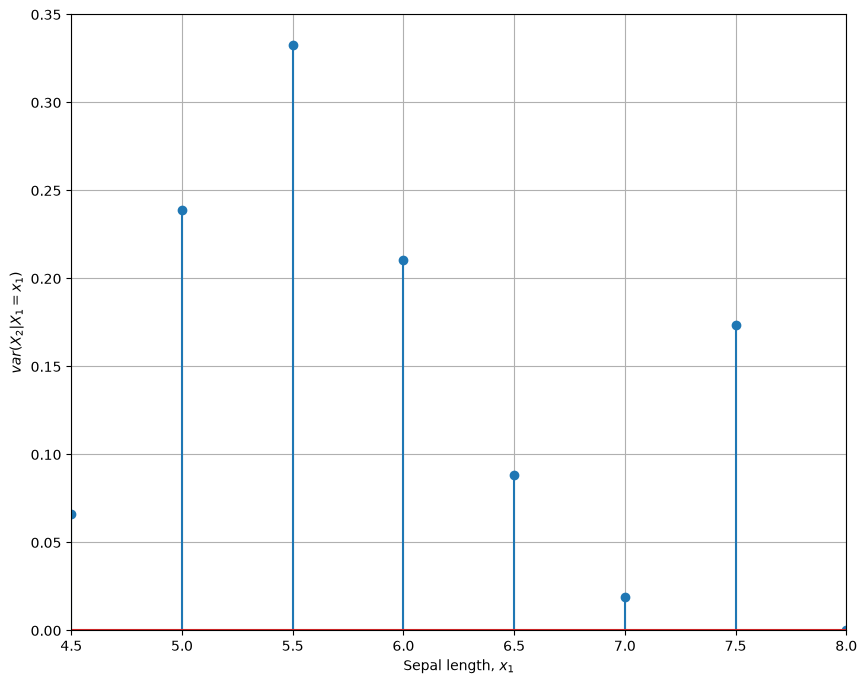

In [30]:
fig, ax = plt.subplots(figsize=(10, 8))
#注意.T,matplotlib只接受1D数组,如果是2D,每一列当做1D数组,这里把2D数组转位2D列(n,1)
plt.stem(X1_array.T, var_X2_given_X1.T) # , use_line_collection=True
plt.xlabel('Sepal length, $x_1$')
plt.ylabel('$var(X_2 | X_1 = x_1)$')
plt.grid()
plt.xlim(4.5, 8.0)
plt.ylim(0, 0.35)
plt.show()

In [31]:
std_X2_given_X1 = np.sqrt(var_X2_given_X1)  # 计算条件标准差

In [34]:
std_X2_given_X1

array([[0.25712974, 0.48884618, 0.57670555, 0.4587254 , 0.29740466,
        0.1381927 , 0.41649656, 0.        ]])

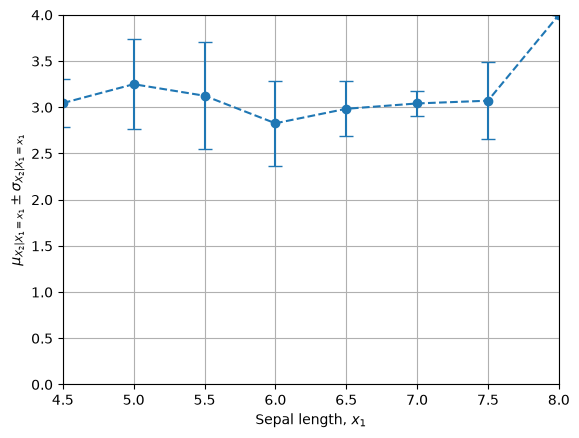

In [32]:
fig, ax = plt.subplots()
ax.errorbar(X1_array[0], E_X2_given_X1[0],
            yerr=std_X2_given_X1[0],
            capsize=5,
            fmt='--o')
plt.xlabel(r'Sepal length, $x_1$')
plt.ylabel(r'$\mu_{X_2 | X_1 = x_1} \pm \sigma_{X_2 | X_1 = x_1} $')
plt.grid()
plt.xlim(4.5, 8.0)
plt.ylim(0, 4)
plt.show()

In [35]:
conditional_X1_given_X2_matrix = probability_matrix_ / (probability_matrix_.sum(axis=1).reshape(-1, 1) @ np.ones((1, 8)))

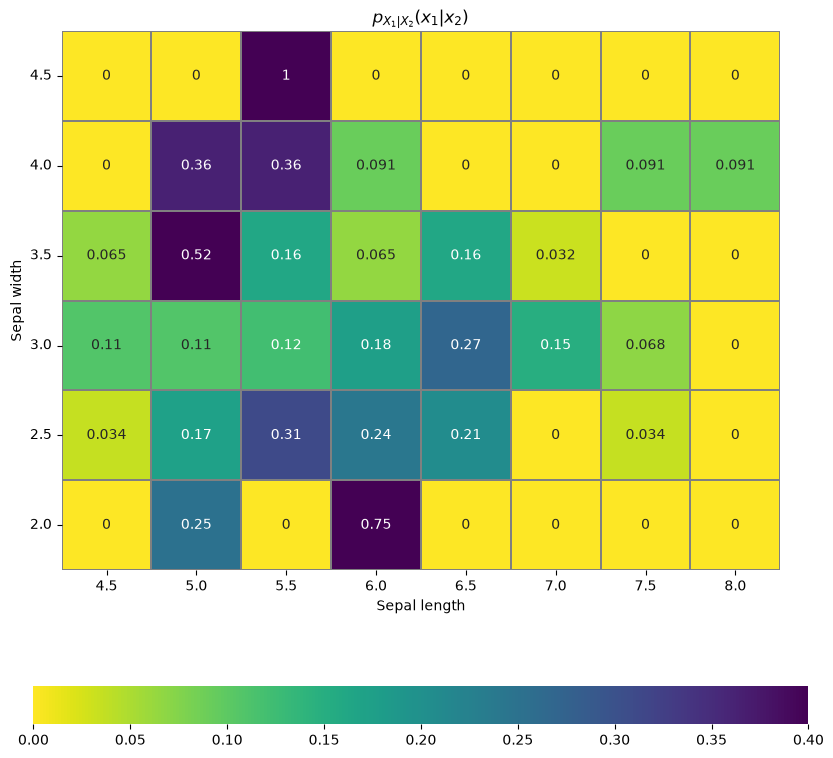

In [36]:
title = '$p_{X_1 | X_2}(x_1 | x_2)$'
heatmap_sum(conditional_X1_given_X2_matrix, sepal_width_array, sepal_length_array, title, 0, 0.4, 'viridis_r')

In [37]:
E_X1_given_X2 = conditional_X1_given_X2_matrix @ X1_array.T  # 计算条件期望

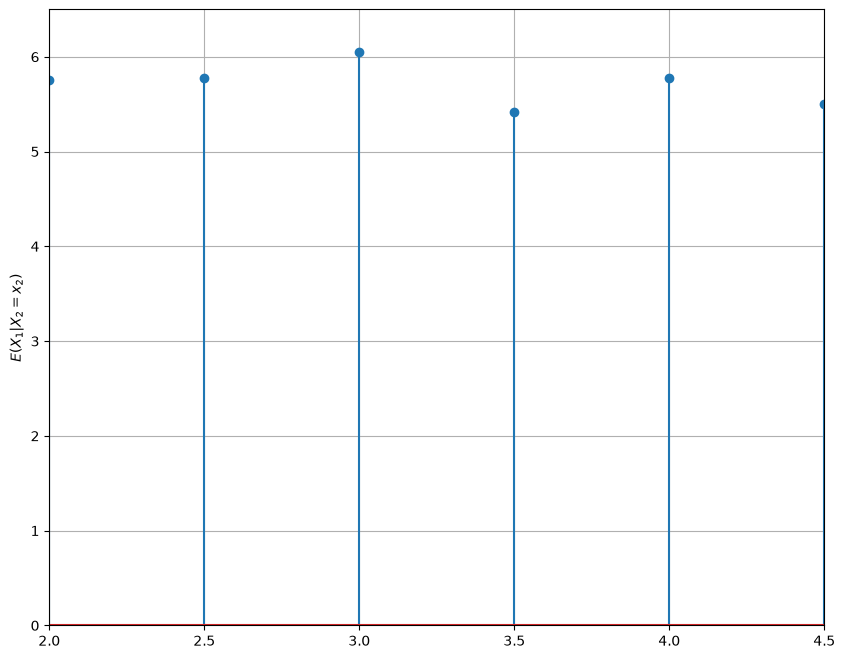

In [38]:
fig, ax = plt.subplots(figsize=(10, 8))
plt.stem(X2_array.T, E_X1_given_X2) #, use_line_collection=True
plt.ylabel('$E(X_1 | X_2 = x_2)$')
plt.grid()
plt.xlim(2, 4.5)
plt.ylim(0, 6.5)
plt.show()

In [39]:
E_X1_sq_given_X2 = conditional_X1_given_X2_matrix @ (X1_array**2).T

In [40]:
var_X1_given_X2 = E_X1_sq_given_X2 - E_X1_given_X2**2  # 条件方差计算

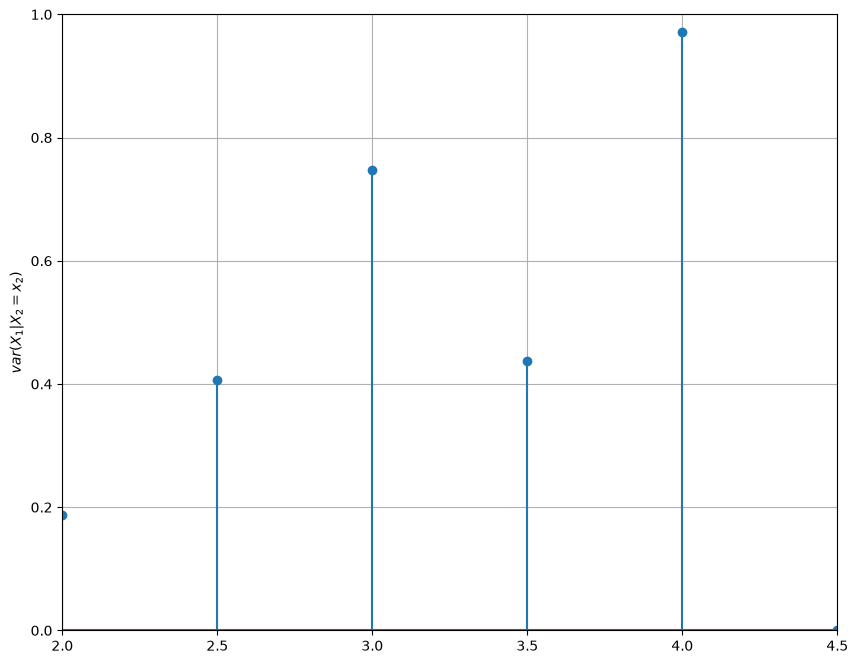

In [41]:
fig, ax = plt.subplots(figsize=(10, 8))
plt.stem(X2_array.T, var_X1_given_X2) #, use_line_collection=True
plt.ylabel('$var(X_1 | X_2 = x_2)$')
plt.grid()
plt.xlim(2, 4.5)
plt.ylim(0, 1)
plt.show()

In [42]:
std_X1_given_X2 = np.sqrt(var_X1_given_X2)  # 计算条件标准差

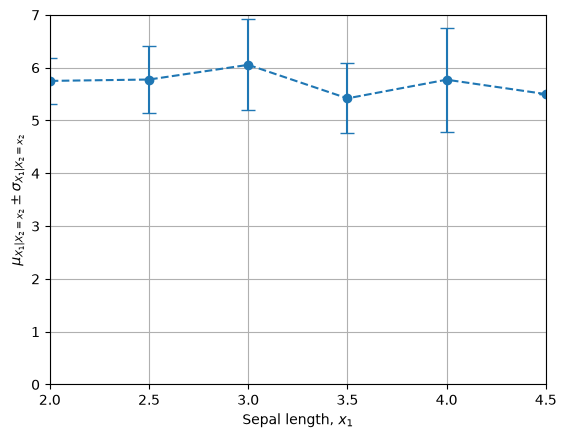

In [43]:
fig, ax = plt.subplots()
ax.errorbar(X2_array[0], E_X1_given_X2.T[0],
            yerr=std_X1_given_X2.T[0],
            capsize=5,
            fmt='--o')
plt.xlabel(r'Sepal length, $x_1$')
plt.ylabel(r'$\mu_{X_1 | X_2 = x_2} \pm \sigma_{X_1 | X_2 = x_2} $')
plt.grid()
plt.xlim(2, 4.5)
plt.ylim(0, 7)
plt.show()

In [44]:
Y_array = ['setosa', 'versicolor', 'virginica']  # 鸢尾花种类

Iris class label:
setosa
E_X1_given_Y: [[5.01]]
E_X1_sq_given_Y: [[25.225]]
var_X1_given_Y: [[0.1249]]
std_X1_given_Y: [[0.35341194]]
E_X2_given_Y: [[3.43]]
E_X2_sq_given_Y: [[11.925]]
var_X2_given_Y: [[0.1601]]
std_X2_given_Y: [[0.40012498]]
Iris class label:
versicolor
E_X1_given_Y: [[5.91]]
E_X1_sq_given_Y: [[35.215]]
var_X1_given_Y: [[0.2869]]
std_X1_given_Y: [[0.53563047]]
E_X2_given_Y: [[2.78]]
E_X2_sq_given_Y: [[7.84]]
var_X2_given_Y: [[0.1116]]
std_X2_given_Y: [[0.33406586]]
Iris class label:
virginica
E_X1_given_Y: [[6.59]]
E_X1_sq_given_Y: [[43.785]]
var_X1_given_Y: [[0.3569]]
std_X1_given_Y: [[0.59741108]]
E_X2_given_Y: [[2.98]]
E_X2_sq_given_Y: [[9.02]]
var_X2_given_Y: [[0.1396]]
std_X2_given_Y: [[0.37363083]]


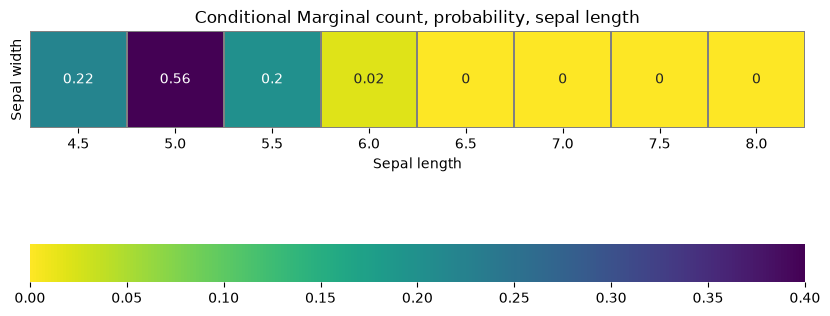

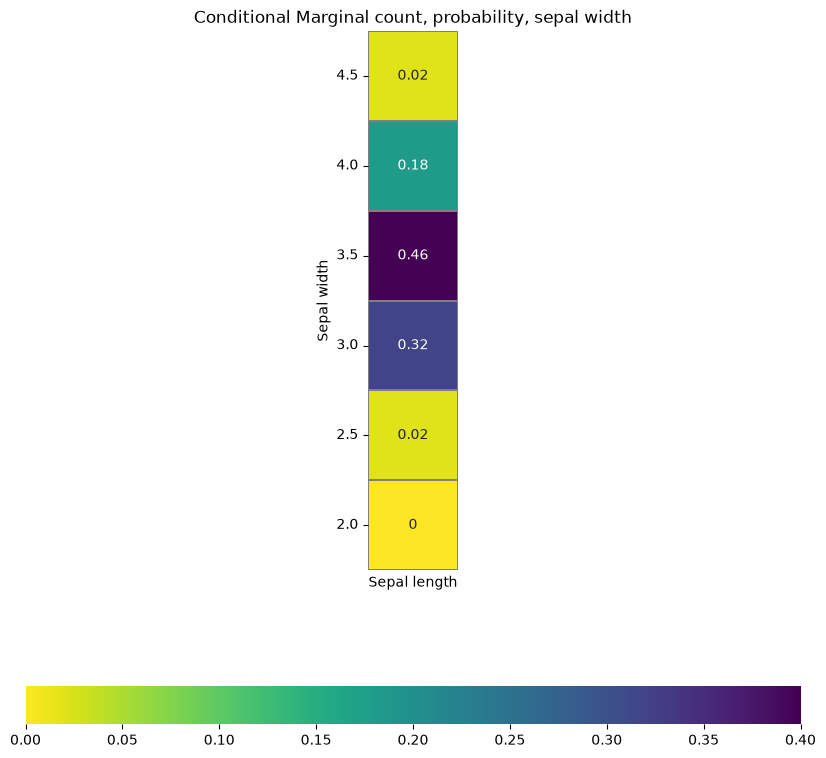

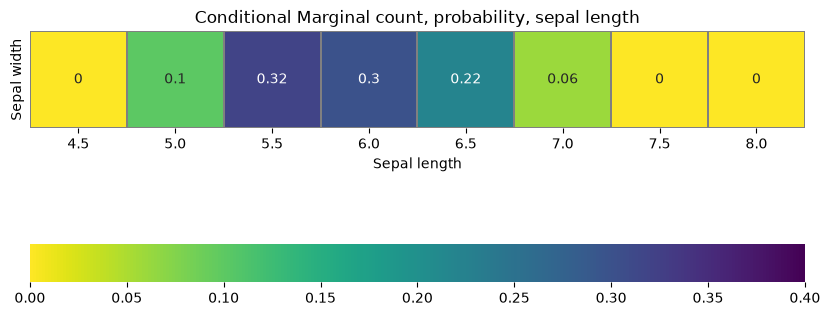

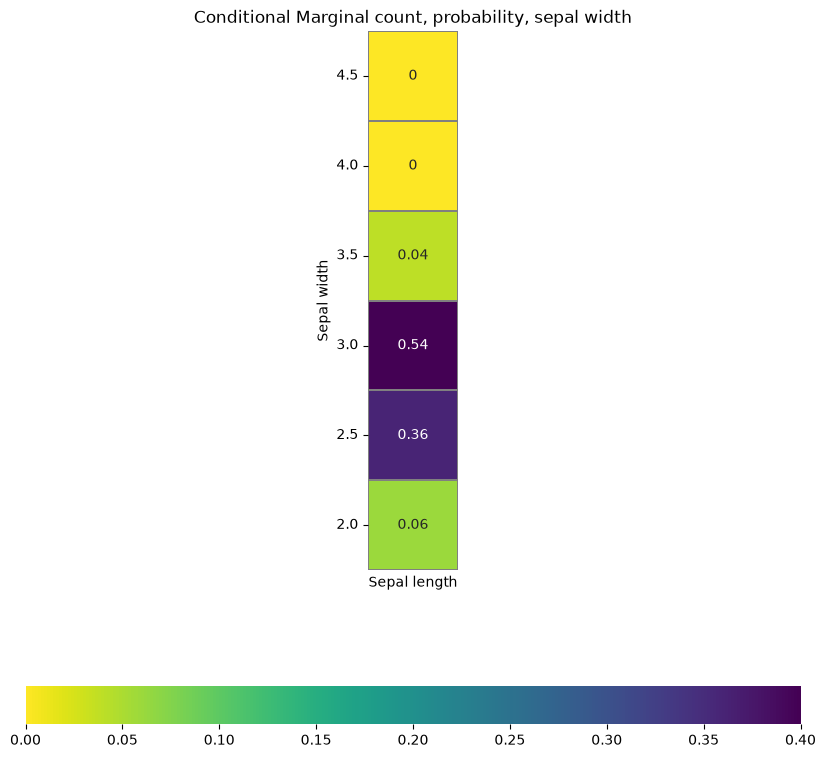

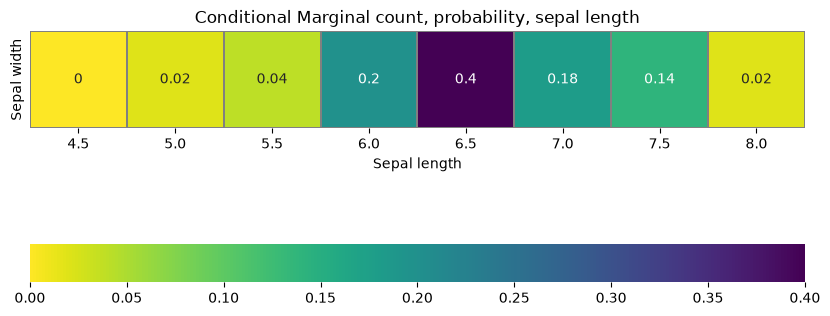

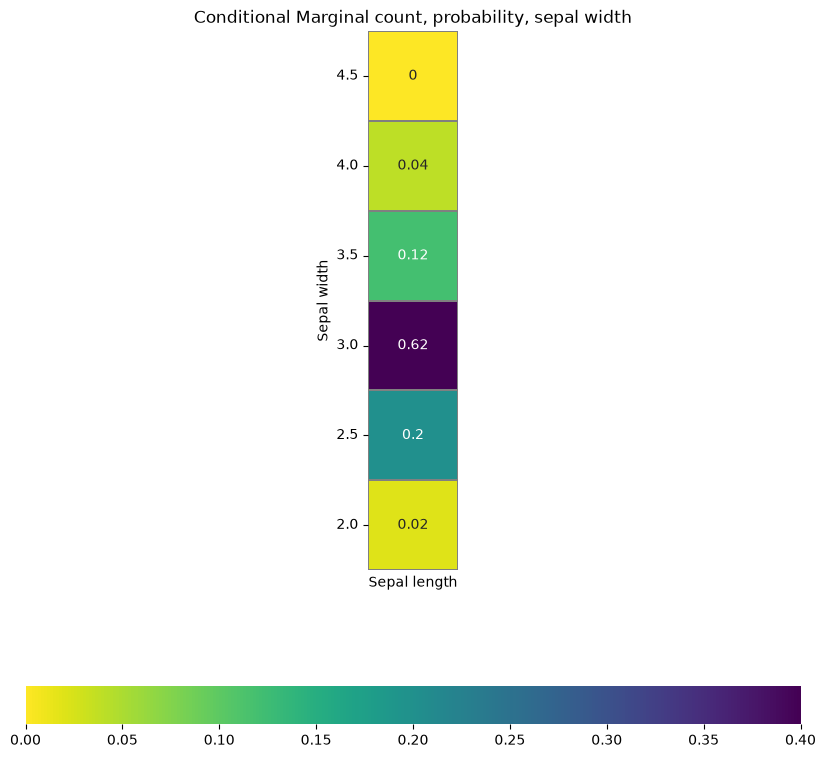

In [45]:
for Given_Y in Y_array:
    print('====================')
    print('Iris class label:')
    print(Given_Y)

    X_df_12_given_Y = X_df[['sepal_length', 'sepal_width', 'species']]
    X_df_12_given_Y['count'] = 1
    X_df_12_given_Y.loc[~(X_df_12_given_Y.species == Given_Y), 'count'] = np.nan
    X_df_12_given_Y = X_df_12_given_Y[['sepal_length', 'sepal_width', 'count']]
    frequency_matrix_given_Y = X_df_12_given_Y.groupby(['sepal_length', 'sepal_width']).count().unstack(level=0)
    frequency_matrix_given_Y.columns = frequency_matrix_given_Y.columns.droplevel(0)
    frequency_matrix_given_Y = frequency_matrix_given_Y.fillna(0).iloc[::-1]
    
    probability_matrix_given_Y = frequency_matrix_given_Y / frequency_matrix_given_Y.sum().sum()

    # 条件边际分布：以花萼长度为条件
    prob_sepal_length_given_Y = probability_matrix_given_Y.sum(axis=0).to_numpy().reshape((1, -1))
    title = 'Conditional Marginal count, probability, sepal length'
    heatmap_sum(prob_sepal_length_given_Y, [], sepal_length_array, title, 0, 0.4, 'viridis_r')

    E_X1_given_Y = prob_sepal_length_given_Y @ sepal_length_array.reshape(-1, 1)
    print('E_X1_given_Y: ' + str(E_X1_given_Y))

    E_X1_sq_given_Y = prob_sepal_length_given_Y @ (sepal_length_array ** 2).reshape(-1, 1)
    print('E_X1_sq_given_Y: ' + str(E_X1_sq_given_Y))

    var_X1_given_Y = E_X1_sq_given_Y - E_X1_given_Y ** 2
    print('var_X1_given_Y: ' + str(var_X1_given_Y))

    std_X1_given_Y = np.sqrt(var_X1_given_Y)
    print('std_X1_given_Y: ' + str(std_X1_given_Y))

    # 条件边际分布：以花萼宽度为条件
    prob_sepal_width_given_Y = probability_matrix_given_Y.sum(axis=1).to_numpy().reshape((-1, 1))
    title = 'Conditional Marginal count, probability, sepal width'
    heatmap_sum(prob_sepal_width_given_Y, sepal_width_array, [], title, 0, 0.4, 'viridis_r')

    E_X2_given_Y = sepal_width_array.reshape(1, -1) @ prob_sepal_width_given_Y
    print('E_X2_given_Y: ' + str(E_X2_given_Y))

    E_X2_sq_given_Y = (sepal_width_array ** 2).reshape(1, -1) @ prob_sepal_width_given_Y
    print('E_X2_sq_given_Y: ' + str(E_X2_sq_given_Y))

    var_X2_given_Y = E_X2_sq_given_Y - E_X2_given_Y ** 2
    print('var_X2_given_Y: ' + str(var_X2_given_Y))

    std_X2_given_Y = np.sqrt(var_X2_given_Y)
    print('std_X2_given_Y: ' + str(std_X2_given_Y))

    print('====================')